In [2]:
!pip install opencv-python
!pip install matplotlib
!pip install numpy

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   - -------------------------------------- 1.3/40.2 MB 16.3 MB/s eta 0:00:03
   ----- ---------------------------------- 5.8/40.2 MB 20.2 MB/s eta 0:00:02
   -------- ------------------------------- 8.9/40.2 MB 18.2 MB/s eta 0:00:02
   ------------- -------------------------- 13.4/40.2 MB 19.2 MB/s eta 0:00:02
   ----------------- ---------------------- 17.8/40.2 MB 19.9 MB/s eta 0:00:02
   -------------------- ------------------- 20.7/40.2 MB 20.0 MB/s eta 0:00:01
   -------------------------- ------------- 27.0/40.2 MB 20.4 MB/s eta 0:00:01
   ------------------------------- -------- 31.5/40.2 MB 20.6 MB/s eta 0:00:01
   ---------------------------------- ----- 35.1/40.2 MB 20.2 MB/s eta 0:00:01
   ---------------------------------------  39.6/40.2 MB 20.4 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 19.2 MB/s  0:00:02


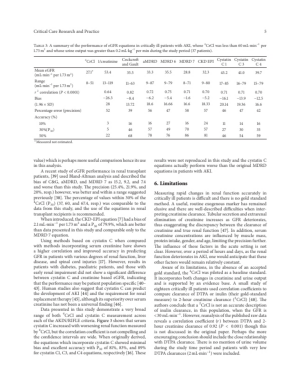

In [3]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("./example.jpg")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

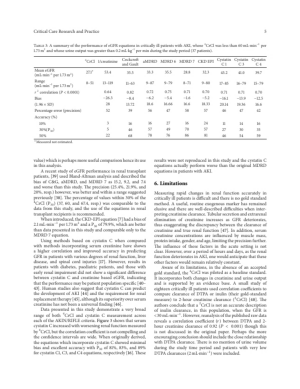

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

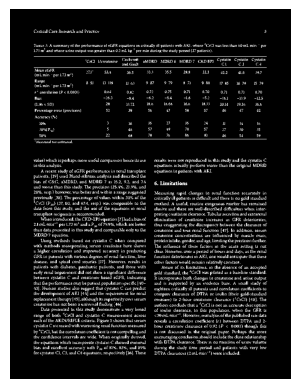

In [5]:
_, thresh = cv2.threshold(
    gray,
    180,
    255,
    cv2.THRESH_BINARY_INV
)

plt.imshow(thresh, cmap="gray")
plt.axis("off")
plt.show()

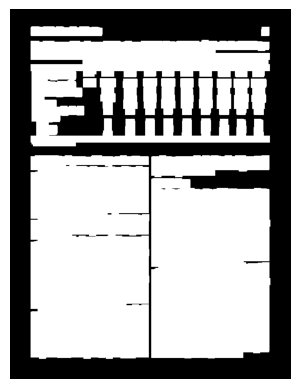

In [6]:
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (15, 15)
)

dilated = cv2.dilate(
    thresh,
    kernel,
    iterations=1
)

plt.imshow(dilated, cmap="gray")
plt.axis("off")
plt.show()

In [7]:
contours, _ = cv2.findContours(
    dilated,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

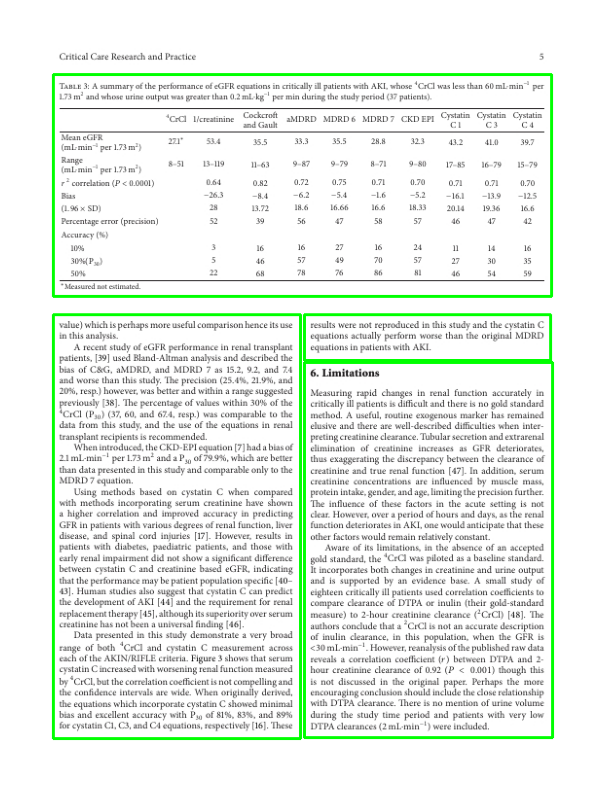

In [8]:
output = img.copy()

for cnt in contours:

    x, y, w, h = cv2.boundingRect(cnt)

    area = w * h

    if area > 5000:

        cv2.rectangle(
            output,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()